In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# a) Read and Split the Data

In [ ]:
features = pd.read_csv("./p3_x.txt", sep="\s+",header=None)
labels = pd.read_csv("./p3_y.txt", sep="\s+", header=None)
features.rename(columns={0:'x1',1:'x2'}, inplace=True)
labels.rename(columns={0:'y'}, inplace=True)
features.head(10)

,x1,x2
0,1.343250,-1.331148
1,1.820553,-0.634668
2,0.986321,-1.888576
3,1.944373,-1.635452
4,0.976734,-1.353315
5,1.945858,-2.044328
6,2.107515,-2.125668
7,2.070373,-2.463410
8,0.868650,-2.411935
9,1.800659,-2.773969


In [51]:
x_shuffled, y_shuffled = shuffle(features, labels, random_state=42)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(x_shuffled, y_shuffled, test_size=0.15, random_state=42)
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

# b) Plot the Data

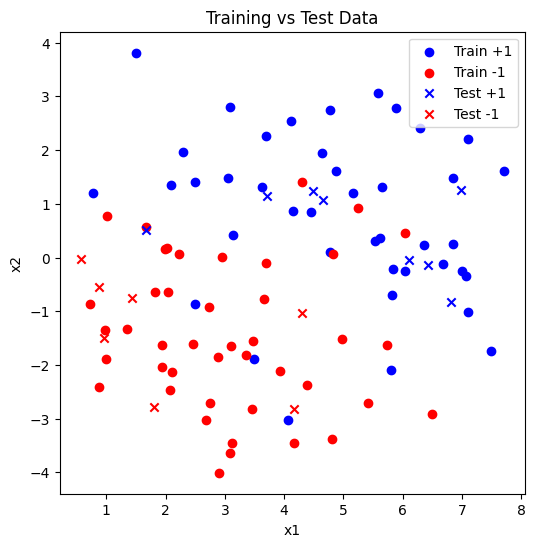

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# Training points
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], c='blue', marker='o', label='Train +1')
plt.scatter(X_train[y_train==-1,0], X_train[y_train==-1,1], c='red', marker='o', label='Train -1')

# Test points
plt.scatter(X_test[y_test==1,0], X_test[y_test==1,1], c='blue', marker='x', label='Test +1')
plt.scatter(X_test[y_test==-1,0], X_test[y_test==-1,1], c='red', marker='x', label='Test -1')

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Training vs Test Data")
plt.show()


# c) Fit the Data with Logistic Regression

In [54]:
model = LogisticRegression()

In [ ]:
model.fit(X_train,y_train)
print("=== Linear Features ===")
print("Train score:", model.score(X_train, y_train))
print("Test score:", model.score(X_test, y_test))

=== Linear Features ===
Train score: 0.8928571428571429
Test score: 0.9333333333333333


In [61]:
import numpy as np

class LogisticRegressionSGD:
    def __init__(self, lr=0.01, n_epochs=1000, batch_size=32, random_state=42):
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.random_state = random_state
        np.random.seed(random_state)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialize weights and bias
        self.w = np.zeros(n_features)
        self.b = 0.0

        # Convert labels from {-1,1} to {0,1}
        y_bin = (y == 1).astype(np.float32)

        for epoch in range(self.n_epochs):
            # Shuffle data
            idx = np.random.permutation(n_samples)
            X, y_bin = X[idx], y_bin[idx]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X[i:i+self.batch_size]
                y_batch = y_bin[i:i+self.batch_size]

                # Predictions
                linear = np.dot(X_batch, self.w) + self.b
                preds = self.sigmoid(linear)

                # Gradients
                error = preds - y_batch
                dw = np.dot(X_batch.T, error) / len(X_batch)
                db = np.mean(error)

                # Update
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.w) + self.b)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.where(probs >= 0.5, 1, -1)

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [62]:
sgd_model = LogisticRegressionSGD(lr=0.01, n_epochs=1000, batch_size=16)
sgd_model.fit(X_train, y_train)

print("SGD Logistic Regression Train Score:", sgd_model.score(X_train, y_train))
print("SGD Logistic Regression Test Score:", sgd_model.score(X_test, y_test))


SGD Logistic Regression Train Score: 0.8809523809523809
SGD Logistic Regression Test Score: 0.9333333333333333


# d) Plotting Decision Boundaries

In [56]:
# %%
# --- Decision Boundary Plot Function ---
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    X = np.asarray(X)
    y = np.asarray(y)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    fig = plt.figure(figsize= (10,6))
    ax = fig.add_subplot(111)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.coolwarm)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    plt.show()


# %%
# --- Decision Boundary Plot Function with list of models ---
def plot_decision_boundary_list(model_list, X, y):
    X = np.asarray(X)
    y = np.asarray(y)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z_list = []
    for i in range(len(model_list)):
        Z = model_list[i].predict(grid)
        Z = Z.reshape(xx.shape)
        Z_list.append(Z)
    fig = plt.figure(figsize=(15, 5))
    fig.suptitle("Decision Boundaries")
    ax1 = fig.add_subplot(131)
    ax1.contourf(xx, yy, Z_list[0], alpha=0.3, cmap=plt.cm.coolwarm)
    ax1.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.coolwarm)
    ax1.set_title("L1-Regularization")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    ax2 = fig.add_subplot(132)
    ax2.contourf(xx, yy, Z_list[1], alpha=0.3, cmap=plt.cm.coolwarm)
    ax2.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.coolwarm)
    ax2.set_title("L2-Regularization")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    ax3 = fig.add_subplot(133)
    ax3.contourf(xx, yy, Z_list[2], alpha=0.3, cmap=plt.cm.coolwarm)
    ax3.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.coolwarm)
    ax3.set_title("Elasticnet Regularization")
    ax3.set_xlabel("x1")
    ax3.set_ylabel("x2")
    plt.show()

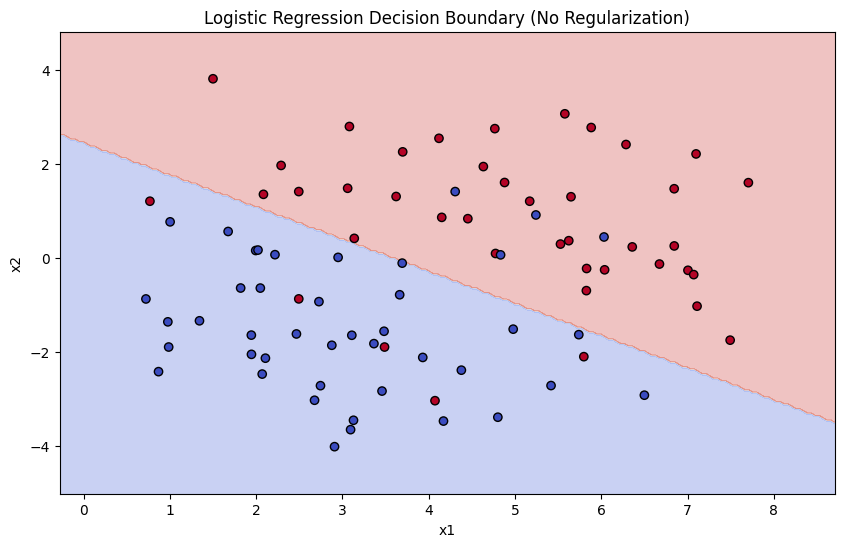

In [57]:
# Plot decision boundaries
plot_decision_boundary(model, X_train, y_train, title="Logistic Regression Decision Boundary (No Regularization)")

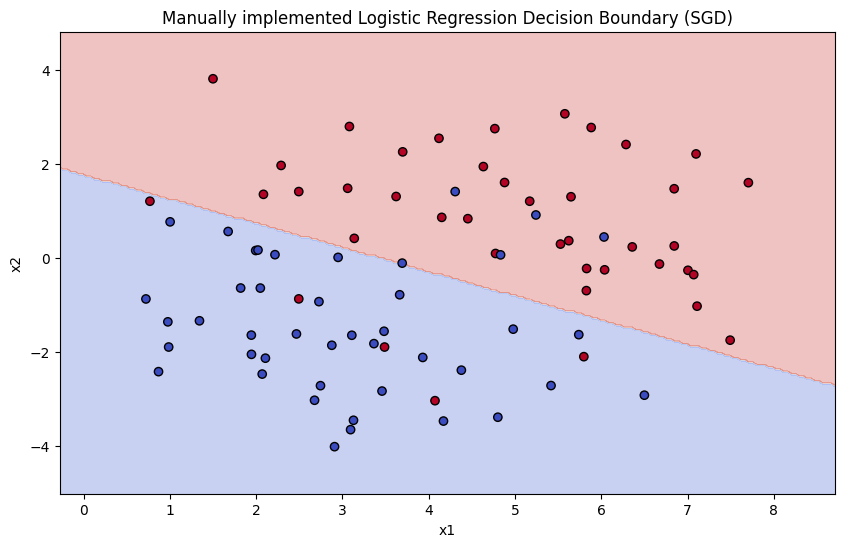

In [64]:
# Plot decision boundaries
plot_decision_boundary(sgd_model, X_train, y_train, title="Manually implemented Logistic Regression Decision Boundary (SGD)")

# e) Trying Different Penalties with the Logistic Regression Algorithm

In [58]:
model_list = []
for penalty in ['l1','l2','elasticnet']:
    if penalty == 'elasticnet':
        solver = 'saga'
        l1_ratio = 0.5
    elif penalty == 'l1':
        solver = 'saga'
        l1_ratio = None
    else:
        solver = 'lbfgs'
        l1_ratio = None
    
    model = LogisticRegression(penalty=penalty, solver=solver, l1_ratio=l1_ratio, max_iter=1000)
    model_list.append(model)
    model.fit(X_train, y_train)
    
    print(f"Penalty: {penalty}, Test score: {model.score(X_test, y_test)}")


Penalty: l1, Test score: 0.9333333333333333
Penalty: l2, Test score: 0.9333333333333333
Penalty: elasticnet, Test score: 0.9333333333333333


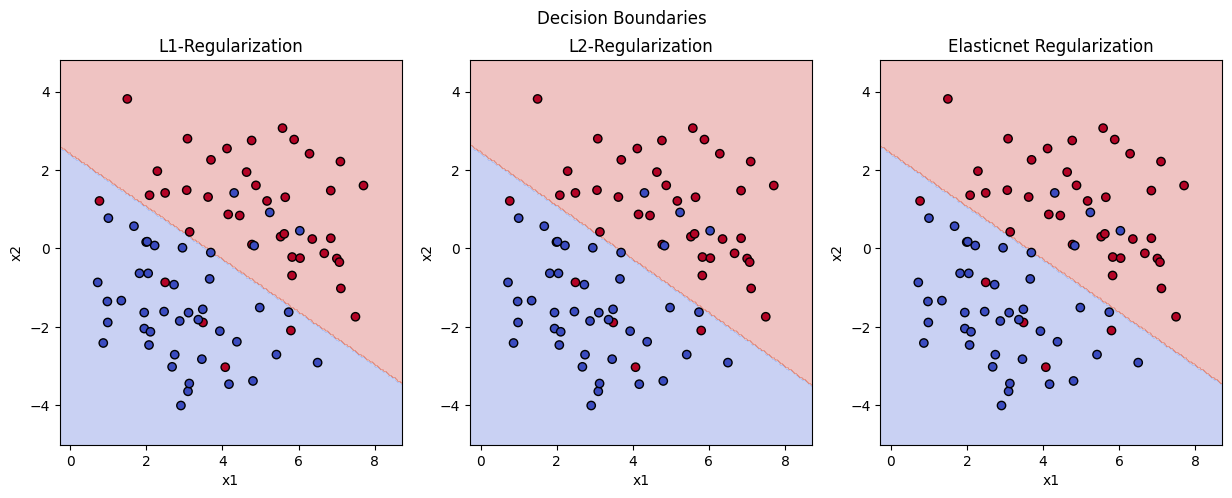

In [59]:
plot_decision_boundary_list(model_list,X_train,y_train)

**Purpose of Penalty**
- Penalty adds regularization.
- It encourages the algorithm to choose small weights.
- L1 tends to make some weights equal to zero.
- L2 penalizes larger weights smoothly compared to L1.
- ElasticNet is a mix of both.

# f) Comparison Between Logistic Regression and SVM

SVM Train score: 0.8809523809523809
SVM Test score: 0.9333333333333333


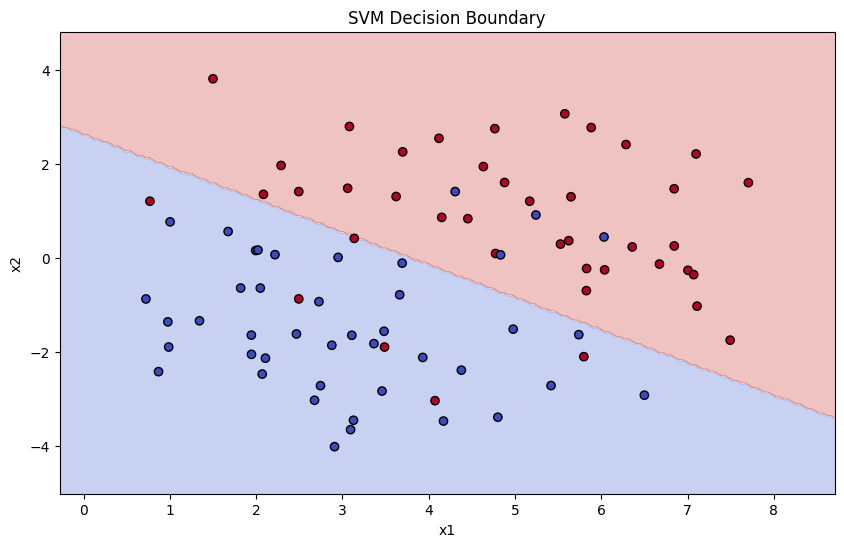

In [60]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

print("SVM Train score:", svm.score(X_train, y_train))
print("SVM Test score:", svm.score(X_test, y_test))
plot_decision_boundary(svm, X_train, y_train, title="SVM Decision Boundary")


**SVM minimizes the hinge loss:**

loss=max(0,1−y(w^Tx+b))
	​

plus an L2 penalty on weights.

# g) 3 Other Classification Algorithms
**k-Nearest Neighbors (k-NN)**: No training needed, works well with simple boundaries, non-parametric.

**Decision Trees**: Handles nonlinear boundaries, interpretable.

**Random Forests**: Ensemble of trees, better generalization, less overfitting.